In [2]:
# Cell 1 — Imports and Configuration

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta

# Optional sklearn metrics for later analysis
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
)

# Display settings
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(120)

# File paths
PRICE_FILE = "polymarket_daily_prices_1000_yes_no_combos.csv"
MARKET_FILE = "polymarket_market_summary_1000_yes_no_combos.csv"
SKIPPED_FILE = "polymarket_skipped_1000_yes_no_combos.csv"

print("Setup complete.")

Setup complete.


In [3]:
# Cell 2 — Load and Verify Data, safer Polars version

prices = pl.read_csv(
    PRICE_FILE,
    infer_schema_length=0,   # read all columns as strings first
    ignore_errors=True,
    truncate_ragged_lines=True,
)

markets = pl.read_csv(
    MARKET_FILE,
    infer_schema_length=0,
    ignore_errors=True,
    truncate_ragged_lines=True,
)

skipped = pl.read_csv(
    SKIPPED_FILE,
    infer_schema_length=0,
    ignore_errors=True,
    truncate_ragged_lines=True,
)

print("Loaded successfully.")
print(f"Prices shape  : {prices.shape}")
print(f"Markets shape : {markets.shape}")
print(f"Skipped shape : {skipped.shape}")

print("\nPrices columns:")
print(prices.columns)

print("\nMarkets columns:")
print(markets.columns)

print("\nPrices preview:")
print(prices.head())

print("\nMarkets preview:")
print(markets.head())

Loaded successfully.
Prices shape  : (9287, 30)
Markets shape : (456, 32)
Skipped shape : (230359, 12)

Prices columns:
['event_title', 'event_slug', 'market_question', 'market_slug', 'condition_id', 'category', 'startDate', 'endDate', 'closedTime', 'volume', 'liquidity', 'lastTradePrice', 'bestBid', 'bestAsk', 'closed', 'resolved', 'active', 'outcomes_raw', 'outcomePrices_raw', 'similarity_group', 'outcome', 'token_id', 'date', 'datetime', 'price', 'hours_to_resolution', 'label', 'winning_outcome', 'winner_type', 'winner_inference_method']

Markets columns:
['event_title', 'event_slug', 'market_question', 'market_slug', 'condition_id', 'category', 'startDate', 'endDate', 'closedTime', 'volume', 'liquidity', 'lastTradePrice', 'bestBid', 'bestAsk', 'closed', 'resolved', 'active', 'outcomes_raw', 'outcomePrices_raw', 'similarity_group', 'winning_outcome', 'winner_type', 'winner_inference_method', 'num_price_rows', 'num_unique_dates', 'first_datetime', 'last_datetime', 'first_price_mean',

In [4]:
# Cell 3 — Clean and Cast Useful Columns

prices_clean = prices.with_columns([
    pl.col("price").cast(pl.Float64),
    pl.col("hours_to_resolution").cast(pl.Float64),
    pl.col("label").cast(pl.Int64),

    pl.col("volume").cast(pl.Float64, strict=False),
    pl.col("liquidity").cast(pl.Float64, strict=False),

    pl.col("datetime").str.to_datetime(
        format="%Y-%m-%d %H:%M:%S%#z",
        strict=False,
    ),

    pl.col("date").str.to_date(
        format="%Y-%m-%d",
        strict=False,
    ),
])

markets_clean = markets.with_columns([
    pl.col("volume").cast(pl.Float64, strict=False),
    pl.col("liquidity").cast(pl.Float64, strict=False),

    pl.col("num_price_rows").cast(pl.Int64, strict=False),
    pl.col("num_unique_dates").cast(pl.Int64, strict=False),

    pl.col("min_price").cast(pl.Float64, strict=False),
    pl.col("max_price").cast(pl.Float64, strict=False),
    pl.col("mean_price").cast(pl.Float64, strict=False),

    pl.col("first_datetime").str.to_datetime(
        format="%Y-%m-%d %H:%M:%S%#z",
        strict=False,
    ),

    pl.col("last_datetime").str.to_datetime(
        format="%Y-%m-%d %H:%M:%S%#z",
        strict=False,
    ),
])

print("Cleaning successful.")

print(prices_clean.schema)
print(markets_clean.schema)

Cleaning successful.
Schema({'event_title': String, 'event_slug': String, 'market_question': String, 'market_slug': String, 'condition_id': String, 'category': String, 'startDate': String, 'endDate': String, 'closedTime': String, 'volume': Float64, 'liquidity': Float64, 'lastTradePrice': String, 'bestBid': String, 'bestAsk': String, 'closed': String, 'resolved': String, 'active': String, 'outcomes_raw': String, 'outcomePrices_raw': String, 'similarity_group': String, 'outcome': String, 'token_id': String, 'date': Date, 'datetime': Datetime(time_unit='us', time_zone='UTC'), 'price': Float64, 'hours_to_resolution': Float64, 'label': Int64, 'winning_outcome': String, 'winner_type': String, 'winner_inference_method': String})
Schema({'event_title': String, 'event_slug': String, 'market_question': String, 'market_slug': String, 'condition_id': String, 'category': String, 'startDate': String, 'endDate': String, 'closedTime': String, 'volume': Float64, 'liquidity': Float64, 'lastTradePrice': 

In [5]:
# Cell 4 — Build Forecast Horizon Snapshots

HORIZONS = {
    "15d": 15 * 24,
    "7d": 7 * 24,
    "1d": 24,
}

snapshot_tables = []

for horizon_name, target_hours in HORIZONS.items():

    # Keep rows BEFORE the target horizon
    eligible = prices_clean.filter(
        pl.col("hours_to_resolution") >= target_hours
    )

    # Find row closest to target horizon
    snapshot = (
        eligible
        .with_columns([
            (
                (pl.col("hours_to_resolution") - target_hours)
                .abs()
            ).alias("distance_to_target")
        ])
        .sort(["condition_id", "distance_to_target"])
        .group_by("condition_id")
        .first()
        .with_columns([
            pl.lit(horizon_name).alias("horizon")
        ])
    )

    snapshot_tables.append(snapshot)

forecast_snapshots = pl.concat(snapshot_tables)

print(forecast_snapshots.shape)

forecast_snapshots.select([
    "market_question",
    "horizon",
    "price",
    "hours_to_resolution",
    "label",
]).head(20)

(1166, 32)


market_question,horizon,price,hours_to_resolution,label
str,str,f64,f64,i64
"""Will the Las Vegas Raiders draft a quarterback in the first round of the 2026 NFL Draft?""","""15d""",0.9495,383.985833,1
"""Will AC Nagano Parceiro vs. Fujieda MYFC end in a draw?""","""15d""",0.605,392.986944,0
"""Will the DHS shutdown end between May 11-17 2026?""","""15d""",0.284,2207.995278,0
"""Will gas hit (High) $4.25 by April 30?""","""15d""",0.375,407.987222,0
"""Will the Fed Pause–Pause–Pause in the next three decisions (Jan–Mar–Apr)?""","""15d""",0.0195,479.992778,0
"""Will President Trump sign 6 pieces of legislation into law in April?""","""15d""",0.145,503.993889,1
"""Will Samira Sagr be in the top 3 of Big Brother Brasil 26?""","""15d""",0.9895,407.985833,1
"""U.S. forces seize another oil tanker by April 30?""","""15d""",0.14,503.9925,1
"""Will Vålerenga Fotball win on 2026-05-03?""","""15d""",0.515,377.245,1


In [6]:
# Cell 5 — Horizon Counts

forecast_snapshots.group_by("horizon").len()

horizon,len
str,u32
"""1d""",456
"""7d""",432
"""15d""",278


In [7]:
# Cell 6 — Brier Scores by Horizon

from sklearn.metrics import brier_score_loss

for horizon in ["15d", "7d", "1d"]:

    subset = forecast_snapshots.filter(
        pl.col("horizon") == horizon
    )

    y_true = subset["label"].to_numpy()
    y_prob = subset["price"].to_numpy()

    score = brier_score_loss(y_true, y_prob)

    print(f"{horizon}: {score:.4f}")

15d: 0.2135
7d: 0.2147
1d: 0.2019


In [8]:
# Cell 9 — Calibration Table Builder

def calibration_table(df, bins=10):

    out = (
        df.with_columns([
            (
                (pl.col("price") * bins)
                .floor()
                .clip(0, bins - 1)
                .cast(pl.Int64)
            ).alias("bin")
        ])
        .group_by("bin")
        .agg([
            pl.len().alias("count"),

            pl.col("price")
            .mean()
            .alias("mean_predicted_prob"),

            pl.col("label")
            .mean()
            .alias("empirical_frequency"),
        ])
        .sort("bin")
    )

    return out

cal_15d = calibration_table(
    forecast_snapshots.filter(pl.col("horizon") == "15d")
)

cal_7d = calibration_table(
    forecast_snapshots.filter(pl.col("horizon") == "7d")
)

cal_1d = calibration_table(
    forecast_snapshots.filter(pl.col("horizon") == "1d")
)

print(cal_1d)

shape: (10, 4)
┌─────┬───────┬─────────────────────┬─────────────────────┐
│ bin ┆ count ┆ mean_predicted_prob ┆ empirical_frequency │
│ --- ┆ ---   ┆ ---                 ┆ ---                 │
│ i64 ┆ u32   ┆ f64                 ┆ f64                 │
╞═════╪═══════╪═════════════════════╪═════════════════════╡
│ 0   ┆ 51    ┆ 0.019275            ┆ 0.039216            │
│ 1   ┆ 20    ┆ 0.152825            ┆ 0.3                 │
│ 2   ┆ 49    ┆ 0.260531            ┆ 0.44898             │
│ 3   ┆ 32    ┆ 0.347969            ┆ 0.34375             │
│ 4   ┆ 56    ┆ 0.448214            ┆ 0.535714            │
│ 5   ┆ 73    ┆ 0.549849            ┆ 0.534247            │
│ 6   ┆ 39    ┆ 0.642705            ┆ 0.538462            │
│ 7   ┆ 56    ┆ 0.744696            ┆ 0.678571            │
│ 8   ┆ 14    ┆ 0.8405              ┆ 0.785714            │
│ 9   ┆ 66    ┆ 0.980523            ┆ 0.878788            │
└─────┴───────┴─────────────────────┴─────────────────────┘


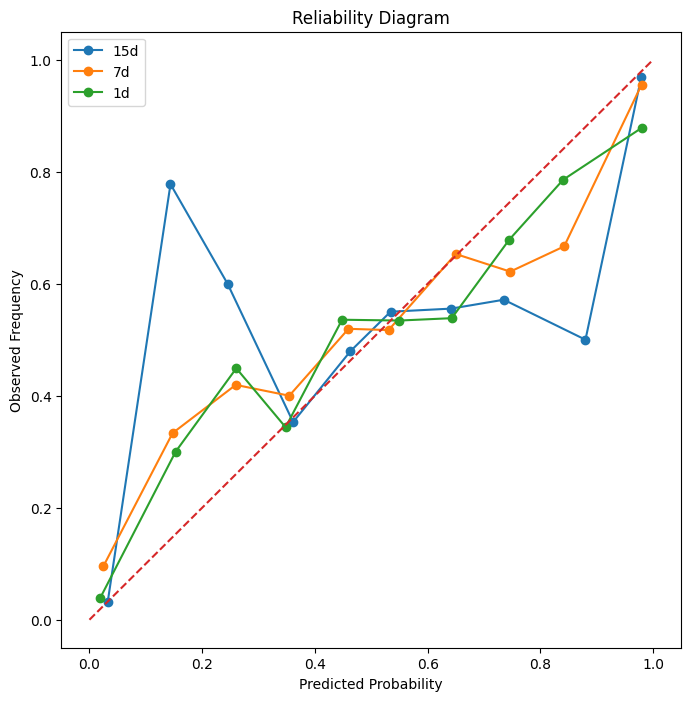

In [9]:
# Cell 10 — Reliability Diagrams

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for cal_table, label in [
    (cal_15d, "15d"),
    (cal_7d, "7d"),
    (cal_1d, "1d"),
]:

    x = cal_table["mean_predicted_prob"].to_numpy()
    y = cal_table["empirical_frequency"].to_numpy()

    plt.plot(x, y, marker="o", label=label)

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram")
plt.legend()

plt.show()

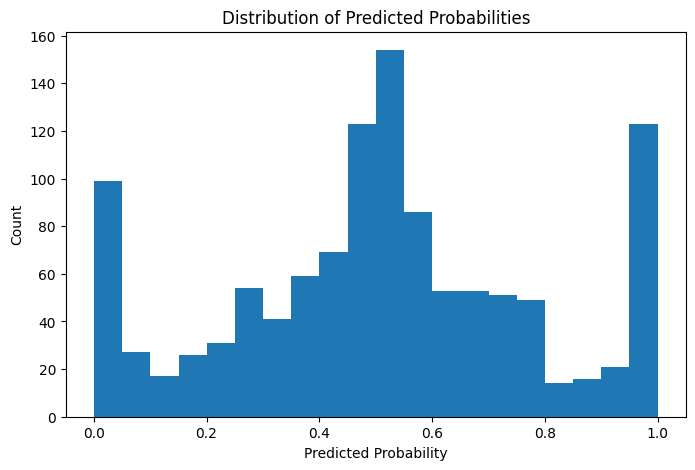

In [10]:
# Cell 11 — Probability Histogram

plt.figure(figsize=(8, 5))

plt.hist(
    forecast_snapshots["price"].to_numpy(),
    bins=20,
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")

plt.show()

In [11]:
# Cell 12 — Log Loss by Horizon

from sklearn.metrics import log_loss

for horizon in ["15d", "7d", "1d"]:

    subset = forecast_snapshots.filter(
        pl.col("horizon") == horizon
    )

    y_true = subset["label"].to_numpy()
    y_prob = subset["price"].to_numpy()

    # Avoid log(0)
    y_prob = np.clip(y_prob, 1e-6, 1 - 1e-6)

    loss = log_loss(y_true, y_prob)

    print(f"{horizon}: {loss:.4f}")

15d: 0.6005
7d: 0.6111
1d: 0.5936


In [12]:
# Cell 13 — Create Liquidity Groups

median_liquidity = (
    forecast_snapshots["liquidity"]
    .drop_nulls()
    .median()
)

print("Median liquidity:", median_liquidity)

forecast_liq = forecast_snapshots.with_columns([
    pl.when(pl.col("liquidity") >= median_liquidity)
    .then(pl.lit("High"))
    .otherwise(pl.lit("Low"))
    .alias("liquidity_group")
])

forecast_liq.group_by("liquidity_group").len()

Median liquidity: 0.0


liquidity_group,len
str,u32
"""Low""",1017
"""High""",149


In [13]:
# Cell 14 — Brier Scores by Liquidity

from sklearn.metrics import brier_score_loss

results = []

for horizon in ["15d", "7d", "1d"]:

    for group in ["High", "Low"]:

        subset = forecast_liq.filter(
            (pl.col("horizon") == horizon) &
            (pl.col("liquidity_group") == group)
        )

        y_true = subset["label"].to_numpy()
        y_prob = subset["price"].to_numpy()

        score = brier_score_loss(y_true, y_prob)

        results.append({
            "horizon": horizon,
            "liquidity_group": group,
            "brier_score": score,
            "count": len(subset),
        })

results_df = pl.DataFrame(results)

print(results_df)

shape: (6, 4)
┌─────────┬─────────────────┬─────────────┬───────┐
│ horizon ┆ liquidity_group ┆ brier_score ┆ count │
│ ---     ┆ ---             ┆ ---         ┆ ---   │
│ str     ┆ str             ┆ f64         ┆ i64   │
╞═════════╪═════════════════╪═════════════╪═══════╡
│ 15d     ┆ High            ┆ 0.188458    ┆ 32    │
│ 15d     ┆ Low             ┆ 0.216712    ┆ 246   │
│ 7d      ┆ High            ┆ 0.214119    ┆ 58    │
│ 7d      ┆ Low             ┆ 0.214755    ┆ 374   │
│ 1d      ┆ High            ┆ 0.201751    ┆ 59    │
│ 1d      ┆ Low             ┆ 0.201902    ┆ 397   │
└─────────┴─────────────────┴─────────────┴───────┘


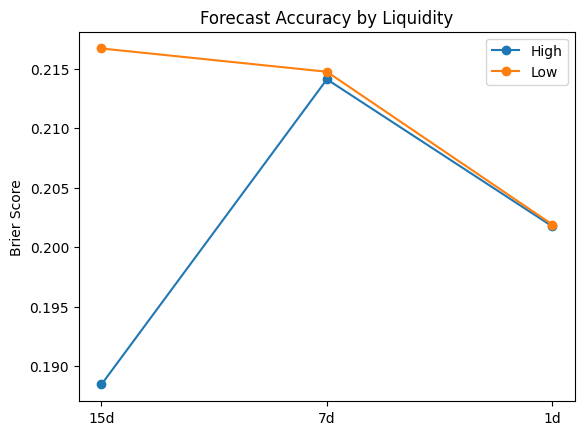

In [14]:
# Cell 15 — Liquidity Comparison Plot

import matplotlib.pyplot as plt

pdf = results_df.to_pandas()

for group in ["High", "Low"]:

    subset = pdf[pdf["liquidity_group"] == group]

    plt.plot(
        subset["horizon"],
        subset["brier_score"],
        marker="o",
        label=group,
    )

plt.ylabel("Brier Score")
plt.title("Forecast Accuracy by Liquidity")
plt.legend()

plt.show()

In [15]:
# Cell 16 — Expected Calibration Error (ECE)

def expected_calibration_error(df, bins=10):

    cal = (
        df.with_columns([
            (
                (pl.col("price") * bins)
                .floor()
                .clip(0, bins - 1)
                .cast(pl.Int64)
            ).alias("bin")
        ])
        .group_by("bin")
        .agg([
            pl.len().alias("count"),

            pl.col("price")
            .mean()
            .alias("mean_predicted_prob"),

            pl.col("label")
            .mean()
            .alias("empirical_frequency"),
        ])
        .with_columns([
            (
                (
                    pl.col("mean_predicted_prob")
                    - pl.col("empirical_frequency")
                )
                .abs()
                * pl.col("count")
            ).alias("weighted_error")
        ])
    )

    total_count = cal["count"].sum()

    ece = (
        cal["weighted_error"].sum()
        / total_count
    )

    return ece, cal


# Compute ECE for each horizon
for horizon in ["15d", "7d", "1d"]:

    subset = forecast_snapshots.filter(
        pl.col("horizon") == horizon
    )

    ece, cal_table = expected_calibration_error(
        subset,
        bins=10,
    )

    print(f"{horizon} ECE: {ece:.4f}") # 1d ECE is worse than the others, could be related to confidence intervals?

15d ECE: 0.0527
7d ECE: 0.0595
1d ECE: 0.0759


In [16]:
# Cell 17 — ECE by Liquidity Group

results = []

for horizon in ["15d", "7d", "1d"]:

    for group in ["High", "Low"]:

        subset = forecast_liq.filter(
            (pl.col("horizon") == horizon) &
            (pl.col("liquidity_group") == group)
        )

        ece, _ = expected_calibration_error(
            subset,
            bins=10,
        )

        results.append({
            "horizon": horizon,
            "liquidity_group": group,
            "ece": ece,
            "count": len(subset),
        })

ece_df = pl.DataFrame(results)

print(ece_df) # might be worth noting that Low Liquidity Group is often higher in count and ECE.

shape: (6, 4)
┌─────────┬─────────────────┬──────────┬───────┐
│ horizon ┆ liquidity_group ┆ ece      ┆ count │
│ ---     ┆ ---             ┆ ---      ┆ ---   │
│ str     ┆ str             ┆ f64      ┆ i64   │
╞═════════╪═════════════════╪══════════╪═══════╡
│ 15d     ┆ High            ┆ 0.087078 ┆ 32    │
│ 15d     ┆ Low             ┆ 0.059465 ┆ 246   │
│ 7d      ┆ High            ┆ 0.07675  ┆ 58    │
│ 7d      ┆ Low             ┆ 0.065638 ┆ 374   │
│ 1d      ┆ High            ┆ 0.117729 ┆ 59    │
│ 1d      ┆ Low             ┆ 0.080238 ┆ 397   │
└─────────┴─────────────────┴──────────┴───────┘


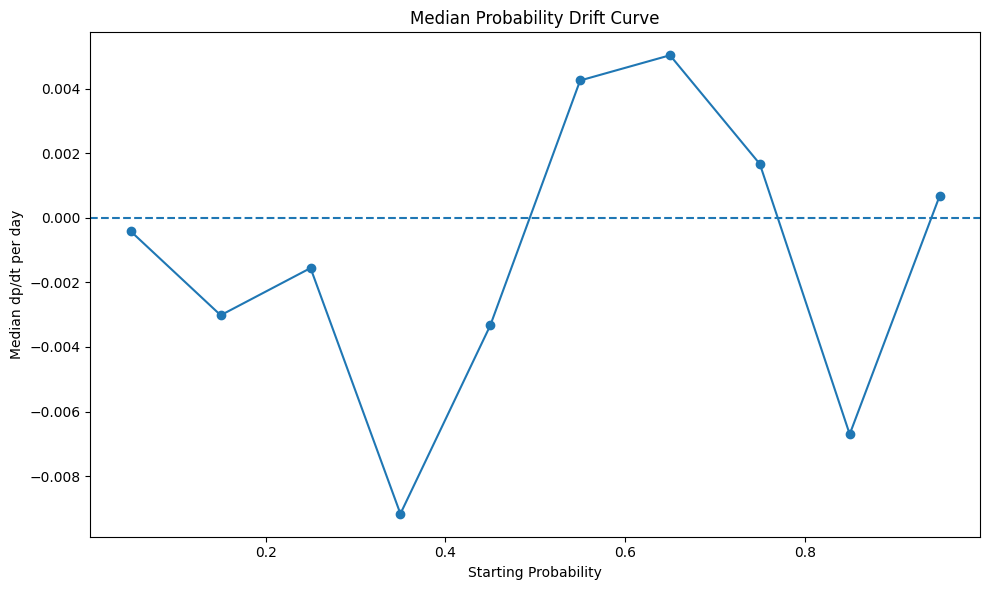

AttributeError: 'Figure' object has no attribute '_root_figure'

In [ ]:
# Cell 18 - Probability drift


drift_base = (
    forecast_snapshots
    .sort(["condition_id", "outcome", "datetime"])
    .with_columns([
        pl.col("price")
        .shift(1)
        .over(["condition_id", "outcome"])
        .alias("prev_price"),

        pl.col("datetime")
        .shift(1)
        .over(["condition_id", "outcome"])
        .alias("prev_datetime"),
    ])
    .with_columns([
        (
            (pl.col("datetime") - pl.col("prev_datetime"))
            .dt.total_hours()
            / 24
        ).alias("dt_days"),

        (pl.col("price") - pl.col("prev_price"))
        .alias("dp"),
    ])
    .filter(
        pl.col("prev_price").is_not_null() &
        pl.col("prev_datetime").is_not_null() &
        (pl.col("dt_days") > 0)
    )
    .with_columns([
        (pl.col("dp") / pl.col("dt_days"))
        .alias("dp_dt"),

        (
            (pl.col("prev_price") * 10)
            .floor()
            .clip(0, 9)
            .cast(pl.Int64)
        ).alias("prob_bin"),
    ])
)


drift_curve = (
    drift_base
    .group_by("prob_bin")
    .agg(
        pl.median("dp_dt").alias("median_dp_dt")
    )
    .sort("prob_bin")
)


drift_pd = drift_curve.to_pandas()

bin_centers = (drift_pd["prob_bin"].to_numpy() + 0.5) / 10
median_drift = drift_pd["median_dp_dt"].to_numpy()

plt.figure(figsize=(10, 6))

plt.plot(
    bin_centers,
    median_drift,
    marker="o",
)

plt.axhline(0, linestyle="--")

plt.xlabel("Starting Probability")
plt.ylabel("Median dp/dt per day")
plt.title("Median Probability Drift Curve")

plt.tight_layout()
plt.show()

# Make a reference probability drift curve

x = np.linspace(0, 1, 1000)
a = 5 * (x - 0.5)
y = np.sin(a)*np.exp(-(a ** 2))

plt.figure(figsize=(10, 6))

plt.plot(x, y)
a = 5 * (bin_centers - 0.5)
y = np.sin(a)*np.exp(-(a ** 2))
plt.plot(bin_centers, y, markets = "o")

plt.axhline(0, linestyle="--")

plt.xlabel("Starting Probability")
plt.ylabel("Median dp/dt per day")
plt.title("Expected Probability Drift Curve")

plt.tight_layout()
plt.show()



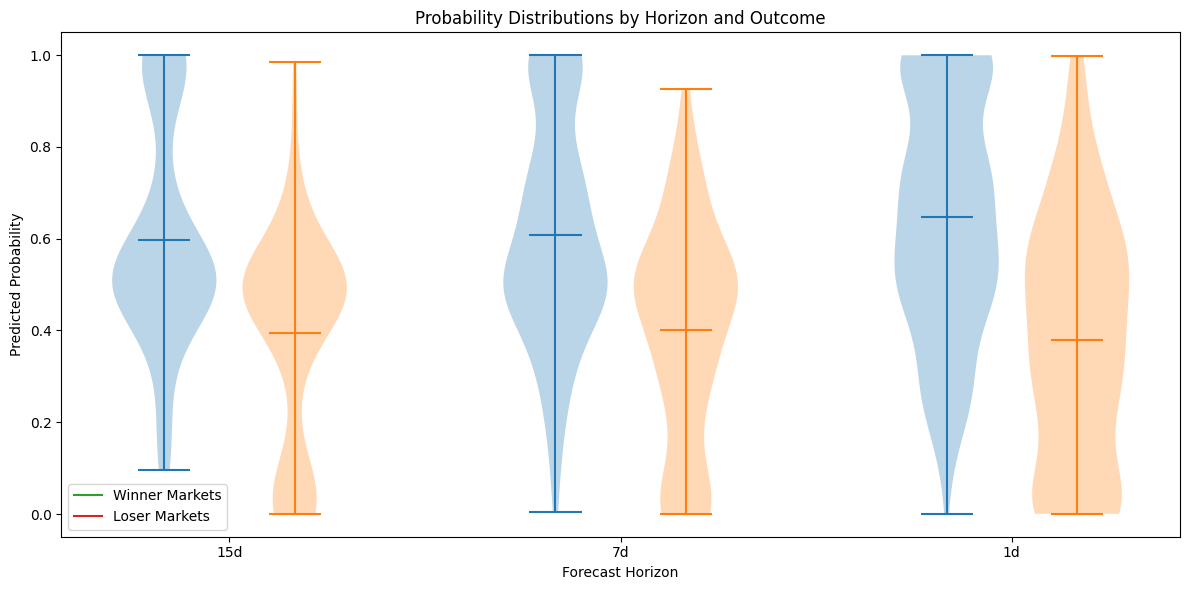

In [ ]:
#Cell 19 - Violin Plots

plot_df = (
    forecast_snapshots
    .select([
        "price",
        "label",
        "horizon",
    ])
    .drop_nulls()
)

horizons = ["15d", "7d", "1d"]

winner_data = []
loser_data = []

for h in horizons:

    winners = (
        plot_df
        .filter(
            (pl.col("horizon") == h) &
            (pl.col("label") == 1)
        )
        .get_column("price")
        .to_numpy()
    )

    losers = (
        plot_df
        .filter(
            (pl.col("horizon") == h) &
            (pl.col("label") == 0)
        )
        .get_column("price")
        .to_numpy()
    )

    winner_data.append(winners)
    loser_data.append(losers)

plt.figure(figsize=(12, 6))

positions_w = [1, 4, 7]
positions_l = [2, 5, 8]

plt.violinplot(
    winner_data,
    positions=positions_w,
    widths=0.8,
    showmeans=True,
)

plt.violinplot(
    loser_data,
    positions=positions_l,
    widths=0.8,
    showmeans=True,
)

plt.xticks(
    [1.5, 4.5, 7.5],
    ["15d", "7d", "1d"]
)

plt.ylabel("Predicted Probability")
plt.xlabel("Forecast Horizon")
plt.title("Probability Distributions by Horizon and Outcome")


plt.plot([], [], label="Winner Markets")
plt.plot([], [], label="Loser Markets")
plt.legend()

plt.tight_layout()
plt.show()